**1. Introduction**



As I am in the initial stages of developing my data science and singer-songwriting careers, I thought it would be appropriate to bring both fields together to inform my analysis and songwriting skills. For this short project, I will be predicting the popularity of songs based purely on song metrics such as key, dancibility, and acousticness. Year, artist, era, and genre will not be included. 


**2. Import Packages**

In [2]:
import numpy as np 
import pandas as pd # for working with dataframes
import seaborn as sns # for data visualization 

from matplotlib import pyplot as plt # for plotting
%matplotlib inline
sns.set_style("whitegrid")

import warnings # http://blog.johnmuellerbooks.com/2015/11/30/warnings-in-python-and-anaconda/
warnings.filterwarnings("ignore")

**3. Loading and Viewing Dataset**

We load the dataset and look at the overall statistics such as mean, count, and median.

In [3]:
dataframe = pd.read_csv('../input/SpotifyFeatures.csv')
dataframe.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:
dataframe.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [5]:
print(dataframe.keys())

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')


A link to the definitions of these features is shown here: https://developer.spotify.com/documentation/web-api/reference/tracks/get-audio-features/

**4. Cleaning NaN Values**

We check for null values. 

In [6]:
pd.isnull(dataframe).sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

Since there are no null values, we don't have to worry about filling in missing information. 

**5. Exploratory Analysis**

We investigate overall trends in the data to get a good idea of which variables correlate with each other as well as other associations.

Text(0.5, 1.0, 'Popularity Distribution')

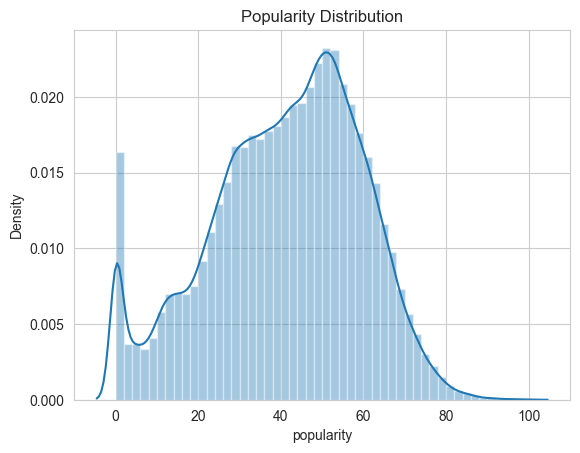

In [7]:
sns.distplot(dataframe['popularity']).set_title('Popularity Distribution')

In [11]:
dataframe.select_dtypes(include="number").corr()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
popularity,1.000000,-0.381295,0.256564,0.002348,0.248922,-0.210983,-0.167995,0.363011,-0.151076,0.081039,0.060076
acousticness,-0.381295,1.000000,-0.364546,0.011203,-0.725576,0.316154,0.069004,-0.690202,0.150935,-0.238247,-0.325798
danceability,0.256564,-0.364546,1.000000,-0.125781,0.325807,-0.364941,-0.041684,0.438668,0.134560,0.021939,0.547154
duration_ms,0.002348,0.011203,-0.125781,1.000000,-0.030550,0.076021,0.023783,-0.047618,-0.016171,-0.028456,-0.141811
energy,0.248922,-0.725576,0.325807,-0.030550,1.000000,-0.378957,0.192801,0.816088,0.145120,0.228774,0.436771
instrumentalness,-0.210983,0.316154,-0.364941,0.076021,-0.378957,1.000000,-0.134198,-0.506320,-0.177147,-0.104133,-0.307522
liveness,-0.167995,0.069004,-0.041684,0.023783,0.192801,-0.134198,1.000000,0.045686,0.510147,-0.051355,0.011804
loudness,0.363011,-0.690202,0.438668,-0.047618,0.816088,-0.506320,0.045686,1.000000,-0.002273,0.228364,0.399901
speechiness,-0.151076,0.150935,0.134560,-0.016171,0.145120,-0.177147,0.510147,-0.002273,1.000000,-0.081541,0.023842
tempo,0.081039,-0.238247,0.021939,-0.028456,0.228774,-0.104133,-0.051355,0.228364,-0.081541,1.000000,0.134857


Text(0.5, 1.0, 'Popularity Based on Time Signature')

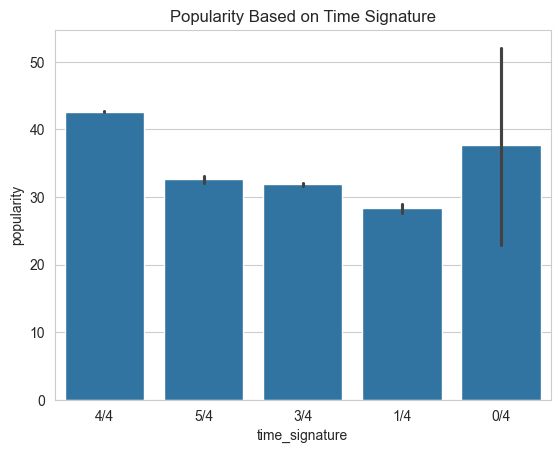

In [12]:
sns.barplot(x = 'time_signature', y = 'popularity', data = dataframe)
plt.title('Popularity Based on Time Signature')

Text(0.5, 1.0, 'Popularity Based on Key')

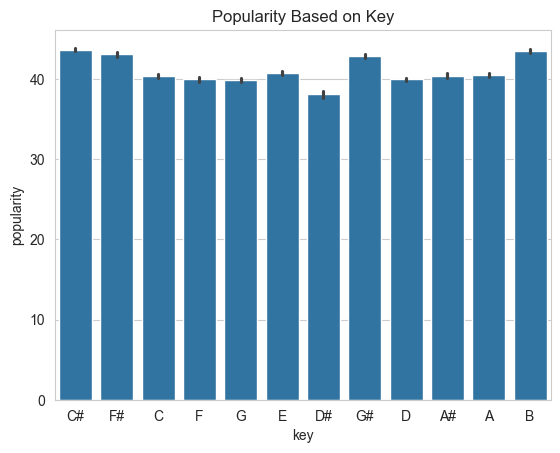

In [13]:
sns.barplot(x = 'key', y = 'popularity', data = dataframe)
plt.title('Popularity Based on Key')

Text(0.5, 1.0, 'Popularity Based on Mode')

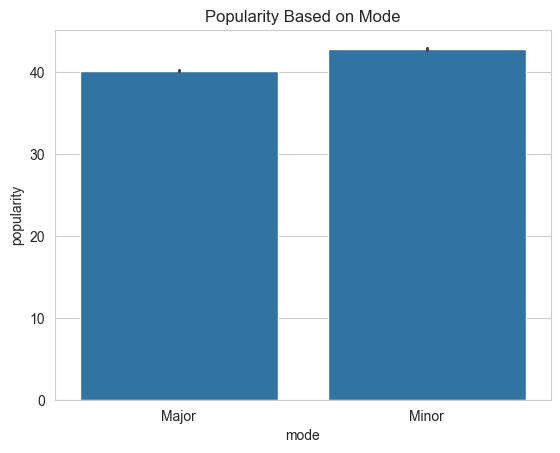

In [14]:
sns.barplot(x = 'mode', y = 'popularity', data = dataframe)
plt.title('Popularity Based on Mode')

Since key and mode are related (there can be A major or A minor), we combine those two features in another barplot using "hue". 

Text(0.5, 1.0, 'Popularity Based on Mode and Key')

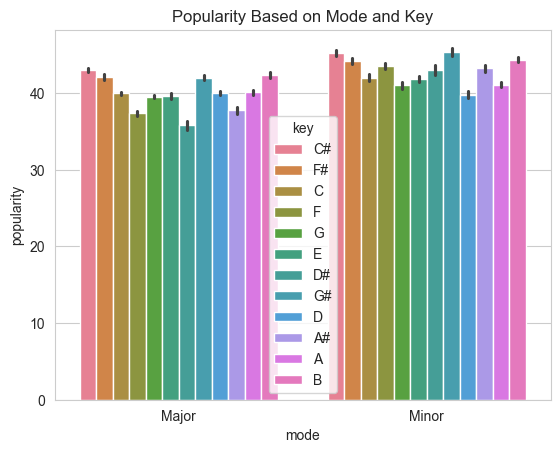

In [15]:
sns.barplot(x = 'mode', y = 'popularity', hue = 'key', data = dataframe)
plt.title('Popularity Based on Mode and Key')

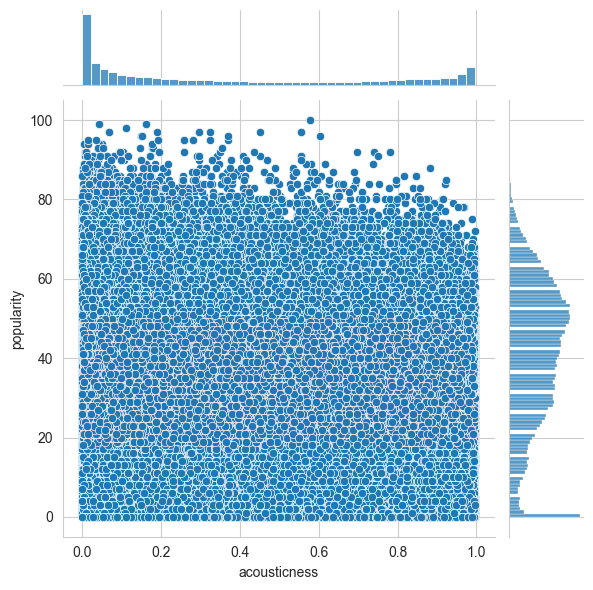

In [16]:
sns.jointplot(x = 'acousticness', y = 'popularity', data = dataframe)

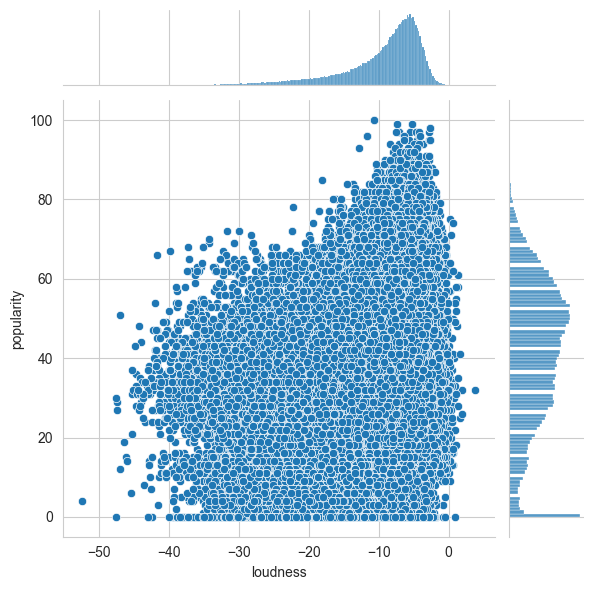

In [17]:
sns.jointplot(x = 'loudness', y = 'popularity', data = dataframe)

Text(0.5, 1.0, 'Acoustiness for Songs with More than 50 Popularity')

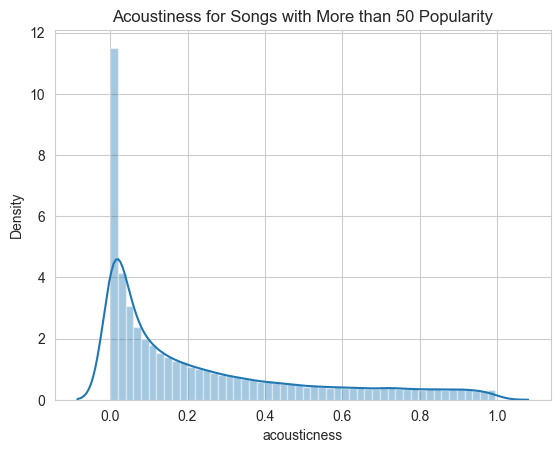

In [18]:
popular_above_50 = dataframe[dataframe.popularity > 50]
sns.distplot(popular_above_50['acousticness'])
plt.title('Acoustiness for Songs with More than 50 Popularity')

Text(0.5, 1.0, 'Acoustiness for Songs with Less than 50 Popularity')

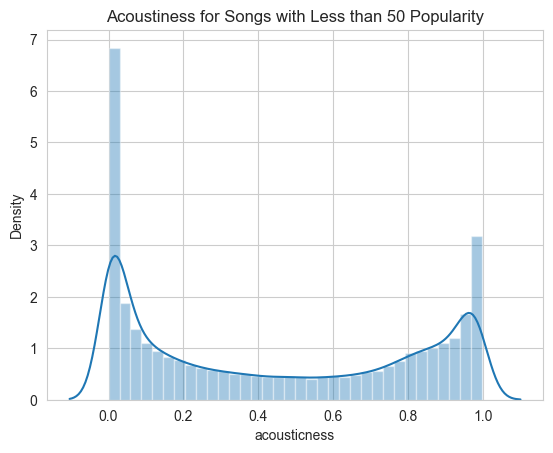

In [19]:
popular_below_50 = dataframe[dataframe.popularity < 50]
sns.distplot(popular_below_50['acousticness'])
plt.title('Acoustiness for Songs with Less than 50 Popularity')

Text(0.5, 1.0, 'Loudness for Songs with More than 50 Popularity')

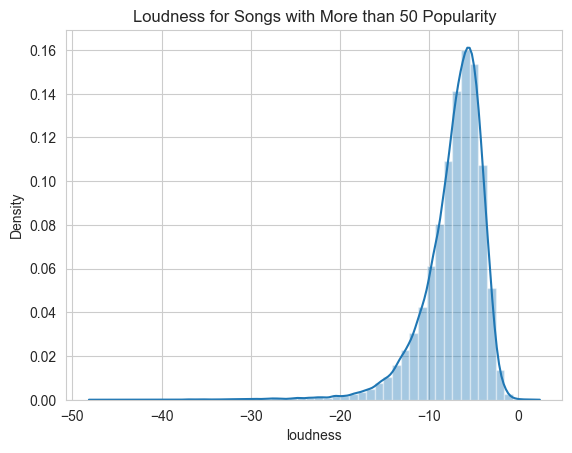

In [20]:
sns.distplot(popular_above_50['loudness'])
plt.title('Loudness for Songs with More than 50 Popularity')
 

Text(0.5, 1.0, 'Loudness for Songs with Less than 50 Popularity')

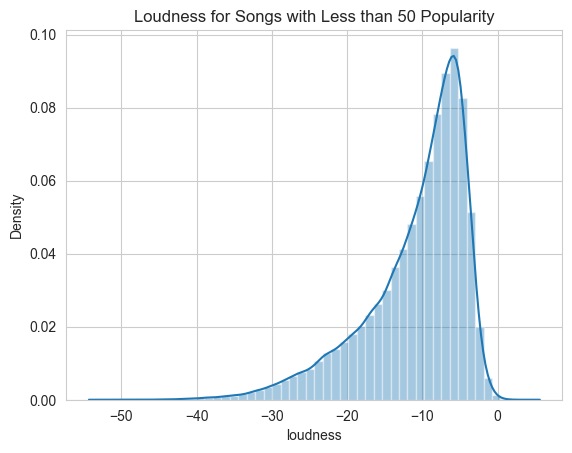

In [21]:
popular_below_50 = dataframe[dataframe.popularity < 50]
sns.distplot(popular_below_50['loudness'])
plt.title('Loudness for Songs with Less than 50 Popularity')

From this analysis, there loudness" and acousticness features have medium-weak correlations with popularity. Furthermore, the distributions of loudness and acousticness differ for songs with more than 50 popularity vs. songs with less than 50 popularity. We plot a summary of all relationships between the features. 

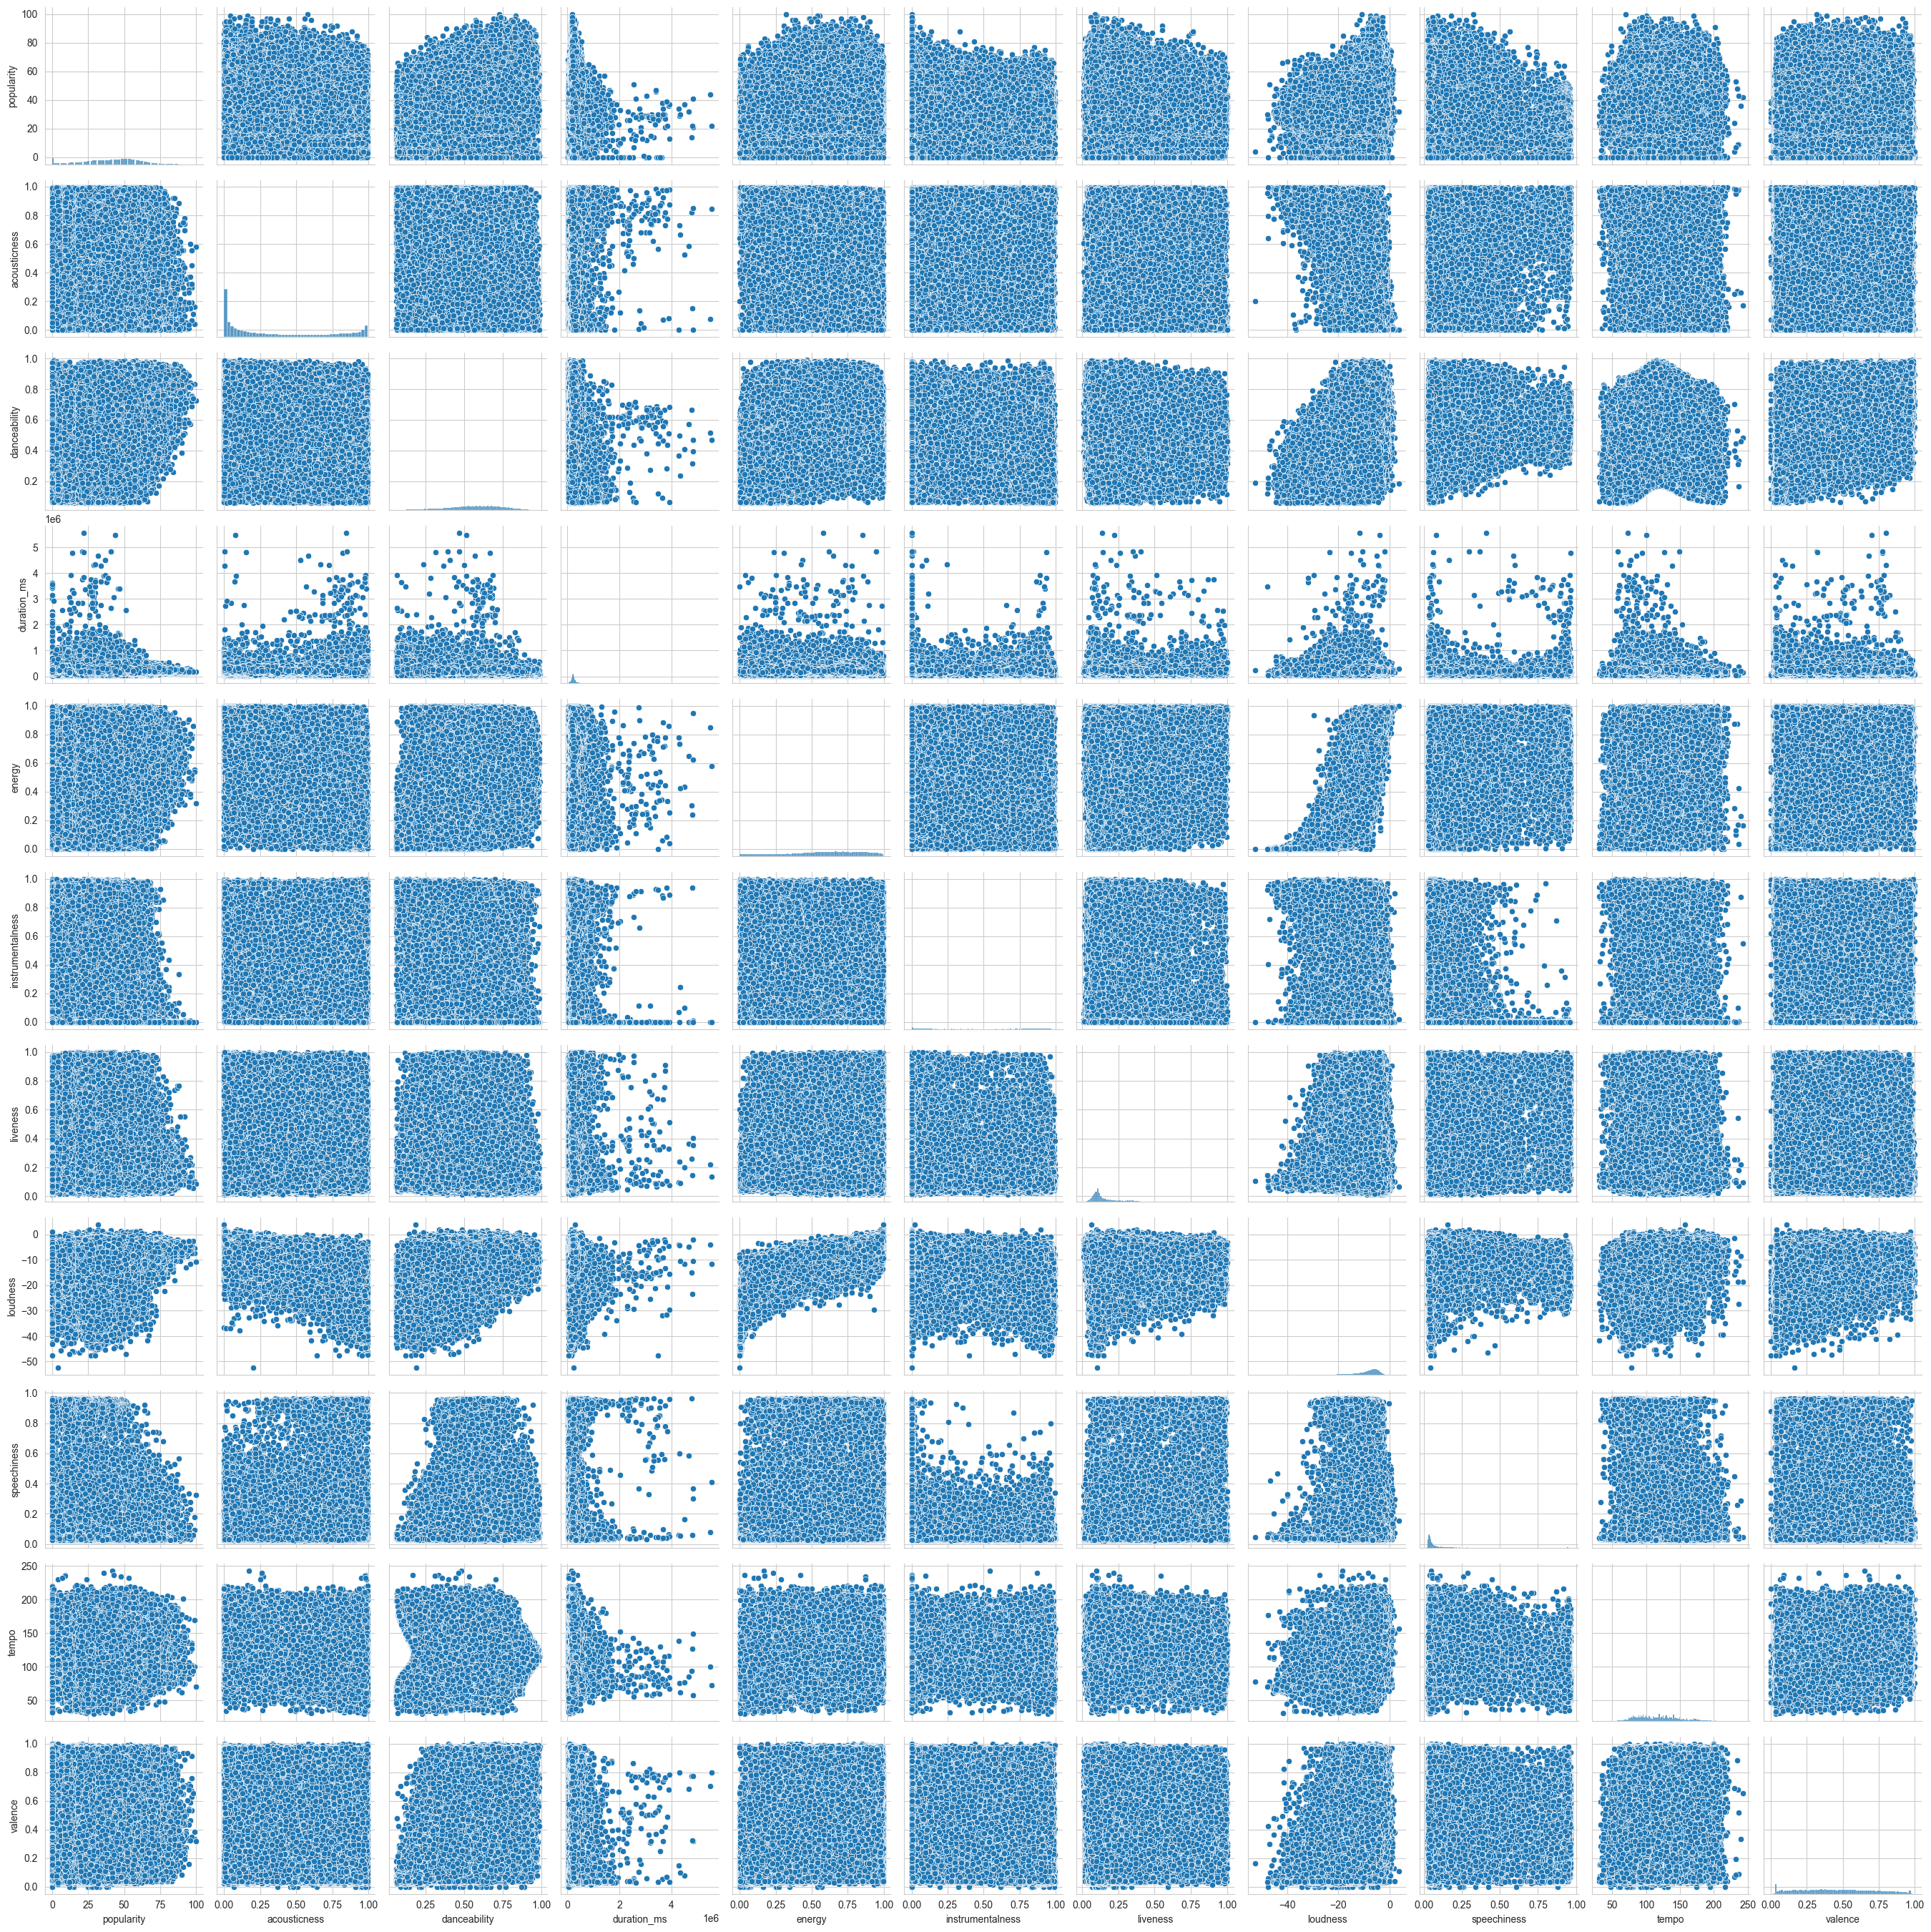

In [22]:
 sns.pairplot(dataframe)

 **6. Feature Engineering**

There are 3 categorical variables (key, mode, and time signature) that need to be converted from text to numbers using one-hot-encoding. We also define popularity as a binary variable. For our purposes, we will define above 57 as "popular" since that's the border of the top 25% of songs and encode that as 1, and below 75 as "not popular" and encode that as 0. 

**Key**: Since there are 12 letter keys (not distinguishing between major and minor), we will convert A to 0, A# to 1, and so on and so forth until B is 12. 

In [23]:
list_of_keys = dataframe['key'].unique()
for i in range(len(list_of_keys)):
    dataframe.loc[dataframe['key'] == list_of_keys[i], 'key'] = i
dataframe.sample(5)

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
117173,Rap,Usher,Burn - Confession Special Edition Version,7z3N2W7Xz1t2G2sAO8wFVH,66,0.314,0.796,231933,0.477,0.000000,0,0.1200,-7.161,Major,0.1080,119.928,4/4,0.685
60855,R&B,Eve,Tambourine,1U16aNzvnlfARgjWXjKmQj,58,0.227,0.825,192440,0.855,0.000000,0,0.3540,-4.155,Major,0.2230,102.631,4/4,0.548
151630,Pop,Taylor Swift,Speak Now,1nYWTzy5zu3zEPNgB1sItW,53,0.095,0.709,240760,0.599,0.000000,4,0.0973,-3.734,Major,0.0304,118.975,4/4,0.735
50031,Blues,Professor Longhair,Go To The Mardi Gras,1O0nWcqmCj32qmFmiu3nGL,27,0.260,0.463,174453,0.704,0.000648,2,0.5540,-7.456,Minor,0.0411,112.145,4/4,0.882
162534,Reggaeton,Ñejo & Dalmata,Triste Y Sola,5a7EaK5IOp5z9gFylsodNL,32,0.418,0.811,195413,0.682,0.000012,9,0.1410,-7.523,Major,0.1050,95.009,4/4,0.687


**Mode**: We will assign major = 1 and minor = 0. 


In [24]:
dataframe.loc[dataframe["mode"] == 'Major', "mode"] = 1
dataframe.loc[dataframe["mode"] == 'Minor', "mode"] = 0
dataframe.sample(5)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
191992,Soul,Blackstreet,No Diggity,6MdqqkQ8sSC0WB4i8PyRuQ,79,0.3030,0.868,304600,0.6460,0.000,0,0.2840,-4.674,0,0.2880,88.641,4/4,0.670
231184,Soul,Sports,Strange to Hear,52OKylOQQSETWtXncZN3L7,43,0.8490,0.537,252800,0.3440,0.957,10,0.1180,-14.782,0,0.0322,176.160,4/4,0.242
129307,Classical,Aram Khachaturian,Cello Concerto in E Minor: III. Allegro,6bX4eF0UjHMVtvlj1gybBZ,25,0.9430,0.239,549000,0.0631,0.947,8,0.0963,-28.970,0,0.0391,125.440,4/4,0.114
74140,Children's Music,Kimbo Children's Music,The Mulberry Bush,6A0b4NeVAXgJthl1WImBBn,0,0.8460,0.845,110440,0.2500,0.000,2,0.1080,-13.181,1,0.0925,124.032,3/4,0.947
40351,Electronic,Flying Lotus,Riot,5XXpEMHnc2mvysbotodu5N,28,0.0568,0.630,242080,0.9490,0.782,5,0.5440,-4.455,0,0.2770,86.655,4/4,0.415


In [25]:
list_of_time_signatures = dataframe['time_signature'].unique()
for i in range(len(list_of_time_signatures)):
    dataframe.loc[dataframe['time_signature'] == list_of_time_signatures[i], 'time_signature'] = i
dataframe.sample(5)

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
224568,Rock,Brandi Carlile,Every Time I Hear That Song,0hoRmVUp5cZ1empu0nSHU8,63,0.54400,0.577,241147,0.530,0.000003,4,0.1030,-6.749,1,0.0312,85.471,0,0.220
17252,Dance,Kiana Ledé,Show Love,2GPnOpA7wBzk0gdZ4MWrwZ,58,0.28100,0.725,178107,0.469,0.000000,8,0.1220,-8.066,0,0.3570,167.036,0,0.470
149390,Pop,Jon Bellion,He Is The Same,11P6ab6Sa2LDOjhiH0kpX7,56,0.23100,0.503,241202,0.555,0.000532,2,0.1180,-4.886,1,0.2270,90.916,0,0.467
56777,R&B,Sammie,P.O.F. (feat. My Family),5kEKtu6hSfTyiQxUu9G1Fp,34,0.36900,0.419,383833,0.264,0.000000,4,0.0853,-19.905,0,0.3700,73.104,2,0.522
37619,Electronic,Dillon Francis,We Are Impossible (feat. The Presets),5S1UdMDFScfvOm3e5LJEDY,33,0.00825,0.659,215280,0.912,0.000000,3,0.5430,-4.212,1,0.0562,109.965,0,0.501


**Popularity**

In [26]:
dataframe.loc[dataframe['popularity'] < 57, 'popularity'] = 0 
dataframe.loc[dataframe['popularity'] >= 57, 'popularity'] = 1
dataframe.loc[dataframe['popularity'] == 1]


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
135,R&B,Mary J. Blige,Be Without You - Kendu Mix,2YegxR5As7BeQuVp2U6pek,1,0.08300,0.724,246333,0.689,0.000000,8,0.3040,-5.922,0,0.1350,146.496,0,0.6930
136,R&B,Rihanna,Desperado,6KFaHC9G178beAp7P0Vi5S,1,0.32300,0.685,186467,0.610,0.000000,2,0.1020,-5.221,0,0.0439,94.384,2,0.3230
137,R&B,Yung Bleu,Ice On My Baby (feat. Kevin Gates) - Remix,6muW8cSjJ3rusKJ0vH5olw,1,0.06750,0.762,199520,0.520,0.000004,3,0.1140,-5.237,0,0.0959,75.047,0,0.0862
138,R&B,Surfaces,Heaven Falls / Fall on Me,7yHqOZfsXYlicyoMt62yC6,1,0.36000,0.563,240597,0.366,0.002430,11,0.0955,-6.896,0,0.1210,85.352,0,0.7680
139,R&B,Olivia O'Brien,Love Myself,4XzgjxGKqULifVf7mnDIQK,1,0.59600,0.653,213947,0.621,0.000000,11,0.0811,-5.721,0,0.0409,100.006,0,0.4660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230312,Soul,James Brown,Get Up (I Feel Like Being A) Sex Machine - Pts...,6hpmTwgNCz81H2bFEREx29,1,0.27300,0.833,318800,0.661,0.000149,9,0.2940,-7.595,0,0.1010,108.314,0,0.8580
230782,Soul,Alex Hepburn,If You Stay,4sJoIeb8zWYCLHSLM0az3b,1,0.04530,0.719,194554,0.702,0.000013,11,0.0662,-4.577,1,0.0357,116.938,0,0.6130
230817,Soul,Paloma Faith,Make Your Own Kind of Music,5jsFFhABp2FkasGr4QcQd6,1,0.00862,0.567,163840,0.753,0.001830,5,0.1270,-4.823,1,0.0406,120.098,0,0.5660
230946,Soul,James Brown,Papa's Got A Brand New Bag - Pt. 1,5aZzmPUv5a2nna9sxBrmpL,1,0.51900,0.775,128973,0.725,0.054100,5,0.0944,-8.369,1,0.0944,129.681,0,0.9140


**7. Model Fitting and Predicting** 

We will use the same models as seen in a previous study on predicting song similarity: https://towardsdatascience.com/song-popularity-predictor-1ef69735e380. For simplicity and using binary classification, we define as the top 25% popular songs as "popular", and the bottom 75% popular songs as "not popular".  

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
from xgboost import XGBClassifier

from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


For feature selection, we will select the following features which are only based on music theory and not artist/song information: acousticness, danceability, duration_ms, energy, instrumentalness, key, liveliness, loudness, mode, speeciness, tempo, time_signature, and valence.

In [32]:
features = ["acousticness", "danceability", "duration_ms", "energy", "instrumentalness", "key", "liveness", 
            "mode", "speechiness", "tempo", "time_signature", "valence"]

Next we define 80% of the dataframe for training and 20% of the dataframe for testing. 

In [33]:
training = dataframe.sample(frac = 0.8,random_state = 420)
X_train = training[features]
y_train = training['popularity']
X_test = dataframe.drop(training.index)[features]

We add a validation dataset using train_test_split. 

In [34]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size = 0.2, random_state = 420)

**Logistic Regression**

In [35]:
LR_Model = LogisticRegression()
LR_Model.fit(X_train, y_train)
LR_Predict = LR_Model.predict(X_valid)
LR_Accuracy = accuracy_score(y_valid, LR_Predict)
print("Accuracy: " + str(LR_Accuracy))

LR_AUC = roc_auc_score(y_valid, LR_Predict) 
print("AUC: " + str(LR_AUC))

Accuracy: 0.7895316360511333
AUC: 0.5


**Random Forest Classifier**

In [36]:
RFC_Model = RandomForestClassifier()
RFC_Model.fit(X_train, y_train)
RFC_Predict = RFC_Model.predict(X_valid)
RFC_Accuracy = accuracy_score(y_valid, RFC_Predict)
print("Accuracy: " + str(RFC_Accuracy))

RFC_AUC = roc_auc_score(y_valid, RFC_Predict) 
print("AUC: " + str(RFC_AUC))

Accuracy: 0.9212858524009023
AUC: 0.8332168026433232


**K-Nearest Neighbors Classifier**

In [37]:
KNN_Model = KNeighborsClassifier()
KNN_Model.fit(X_train, y_train)
KNN_Predict = KNN_Model.predict(X_valid)
KNN_Accuracy = accuracy_score(y_valid, KNN_Predict)
print("Accuracy: " + str(KNN_Accuracy))

KNN_AUC = roc_auc_score(y_valid, KNN_Predict) 
print("AUC: " + str(KNN_AUC))

Accuracy: 0.7737673219465034
AUC: 0.6155142655122736


**Decision Tree Classifier**

In [38]:
DT_Model = DecisionTreeClassifier()
DT_Model.fit(X_train, y_train)
DT_Predict = DT_Model.predict(X_valid)
DT_Accuracy = accuracy_score(y_valid, DT_Predict)
print("Accuracy: " + str(DT_Accuracy))

DT_AUC = roc_auc_score(y_valid, DT_Predict) 
print("AUC: " + str(DT_AUC))

Accuracy: 0.852588892469653
AUC: 0.8121255492562731


**Linear Support Vector Classification**

Since LSVC is O(n^3), and the training data set has 182,000 datapoints, it would take 10^15 operations to train the model. Therefore we will only use 10000 datapoints total. 

In [39]:
training_LSVC = training.sample(10000)
X_train_LSVC = training_LSVC[features]
y_train_LSVC = training_LSVC['popularity']
X_test_LSVC = dataframe.drop(training_LSVC.index)[features]
X_train_LSVC, X_valid_LSVC, y_train_LSVC, y_valid_LSVC = train_test_split(
    X_train_LSVC, y_train_LSVC, test_size = 0.2, random_state = 420)


In [49]:
LSVC_Model = DecisionTreeClassifier()
LSVC_Model.fit(X_train_LSVC, y_train_LSVC)
LSVC_Predict = LSVC_Model.predict(X_valid_LSVC)
LSVC_Accuracy = accuracy_score(y_valid_LSVC, LSVC_Predict)
print("Accuracy: " + str(LSVC_Accuracy))

LSVC_AUC = roc_auc_score(y_valid_LSVC, LSVC_Predict) 
print("AUC: " + str(LSVC_AUC))

Accuracy: 0.715
AUC: 0.5709103534144239


**XGBOOST**

In [50]:
XGB_Model = XGBClassifier(objective = "binary:logistic", n_estimators = 10, seed = 123)
XGB_Model.fit(X_train, y_train)
XGB_Predict = XGB_Model.predict(X_valid)
XGB_Accuracy = accuracy_score(y_valid, XGB_Predict)
print("Accuracy: " + str(XGB_Accuracy))

XGB_AUC = roc_auc_score(y_valid, XGB_Predict) 
print("AUC: " + str(XGB_AUC))

Accuracy: 1.0
AUC: nan


**8. Model Performance Summary**

In [51]:
model_performance_accuracy = pd.DataFrame({'Model': ['LogisticRegression', 
                                                      'RandomForestClassifier', 
                                                      'KNeighborsClassifier',
                                                      'DecisionTreeClassifier',
                                                      'LinearSVC',
                                                      'XGBClassifier'],
                                            'Accuracy': [LR_Accuracy,
                                                         RFC_Accuracy,
                                                         KNN_Accuracy,
                                                         DT_Accuracy,
                                                         LSVC_Accuracy,
                                                         XGB_Accuracy]})

model_performance_AUC = pd.DataFrame({'Model': ['LogisticRegression', 
                                                      'RandomForestClassifier', 
                                                      'KNeighborsClassifier',
                                                      'DecisionTreeClassifier',
                                                      'LinearSVC',
                                                      'XGBClassifier'],
                                            'AUC': [LR_AUC,
                                                         RFC_AUC,
                                                         KNN_AUC,
                                                         DT_AUC,
                                                         LSVC_AUC,
                                                         XGB_AUC]})

In [52]:
model_performance_accuracy.sort_values(by = "Accuracy", ascending = False)

,Model,Accuracy
5,XGBClassifier,1.000000
1,RandomForestClassifier,0.921286
3,DecisionTreeClassifier,0.852589
0,LogisticRegression,0.789532
2,KNeighborsClassifier,0.773767
4,LinearSVC,0.715000


In [53]:
model_performance_AUC.sort_values(by = "AUC", ascending = False)

,Model,AUC
1,RandomForestClassifier,0.833217
3,DecisionTreeClassifier,0.812126
2,KNeighborsClassifier,0.615514
4,LinearSVC,0.570910
0,LogisticRegression,0.500000
5,XGBClassifier,NaN


**9. Conclusion**

Using a dataset of 228,000 Spotify Tracks, we were able to predict popularity (greater than 57 popularity) using audio-based metrics such as key, mode, and danceability without external metrics such as artist name, genre, and release date. The Random Forest Classifier was the best performing algorithm with 92.0% accuracy and 86.4% AUC. The Decision Tree Classifier was the second best performing algorithm with 87.5% accuracy and 85.8% AUC.

Moving forward, I will use a larger Spotify database by using the Spotify API to collect my own data, and explore different algorithms to predict popularity score rather than doing binary classification. 

**10. References**

1. Cher Lau-Cher Lau - https://towardsdatascience.com/5-steps-of-a-data-science-project-lifecycle-26c50372b492
2. Are Hit Songs Becoming Less Musically Diverse?
Andrew Thompson-Matt Daniels-Damián Gaume - https://pudding.cool/2018/05/similarity/
3. Song Popularity Predictor
Mohamed Nasreldin-Mohamed Nasreldin - https://towardsdatascience.com/song-popularity-predictor-1ef69735e380
4. Titanic: Beginner's Guide with Sklearn
https://www.kaggle.com/ialimustafa/titanic-beginner-s-guide-with-sklearn/data
5. **Data Source:** https://www.kaggle.com/zaheenhamidani/ultimate-spotify-tracks-db#SpotifyFeatures.csv